In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error

import os
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving sales_data_april_2019.csv to sales_data_april_2019 (1).csv
Saving sales_data_august_2019.csv to sales_data_august_2019 (1).csv
Saving sales_data_december_2019.csv to sales_data_december_2019 (1).csv
Saving sales_data_february_2019.csv to sales_data_february_2019 (1).csv
Saving sales_data_january_2019.csv to sales_data_january_2019 (1).csv
Saving sales_data_july_2019.csv to sales_data_july_2019 (1).csv
Saving sales_data_june_2019.csv to sales_data_june_2019 (1).csv
Saving sales_data_march_2019.csv to sales_data_march_2019 (1).csv
Saving sales_data_may_2019.csv to sales_data_may_2019 (1).csv
Saving sales_data_november_2019.csv to sales_data_november_2019 (1).csv
Saving sales_data_october_2019.csv to sales_data_october_2019 (1).csv
Saving sales_data_september_2019.csv to sales_data_september_2019 (1).csv


In [ ]:
df_list = []

for file in uploaded.keys():
    temp = pd.read_csv(file)
    df_list.append(temp)

df = pd.concat(df_list, ignore_index=True)

df.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
1,NaN,NaN,NaN,NaN,NaN,NaN
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"


dataset terdiri dari beberapa file bulanan sehingga saya gabungkan menjadi satu dataframe

In [ ]:
df.info()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186850 entries, 0 to 186849
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Order ID          186305 non-null  object
 1   Product           186305 non-null  object
 2   Quantity Ordered  186305 non-null  object
 3   Price Each        186305 non-null  object
 4   Order Date        186305 non-null  object
 5   Purchase Address  186305 non-null  object
dtypes: object(6)
memory usage: 8.6+ MB


np.int64(1162)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.columns

Index(['Order ID', 'Product', 'Quantity Ordered', 'Price Each', 'Order Date',
       'Purchase Address'],
      dtype='object')

In [ ]:
df.columns = df.columns.str.strip()

df = df[df['Quantity Ordered'] != 'Quantity Ordered']

df['Quantity Ordered'] = pd.to_numeric(df['Quantity Ordered'])
df['Price Each'] = pd.to_numeric(df['Price Each'])

df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
df = df.dropna(subset=['Order Date'])

df['Revenue'] = df['Price Each'] * df['Quantity Ordered']

df['City'] = df['Purchase Address'].apply(lambda x: x.split(',')[1])

df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Day'] = df['Order Date'].dt.day
df['Week'] = df['Order Date'].dt.isocalendar().week
df['Hour'] = df['Order Date'].dt.hour

ditemukan adanya baris yang berisi header di dalam data sehingga perlu dibersihkan. selain itu, tipe data pada kolom numerik masih berupa string sehingga perlu dikonversi

In [ ]:
df_2019 = df[df['Year'] == 2019]

total_revenue = df_2019['Revenue'].sum()
total_order = df_2019['Order ID'].nunique()
total_items = df_2019['Quantity Ordered'].sum()

avg_items_per_order = total_items / total_order
avg_spending_per_order = total_revenue / total_order

print("Total Revenue:", total_revenue)
print("Total Order:", total_order)
print("Total Items:", total_items)
print("Avg Items/Order:", avg_items_per_order)
print("Avg Spending/Order:", avg_spending_per_order)

Total Revenue: 34456867.65
Total Order: 178406
Total Items: 208771
Avg Items/Order: 1.170201674831564
Avg Spending/Order: 193.1373813100456


perhitungan ini digunakan untuk melihat performa bisnis secara keseluruhan selama tahun 2019

In [ ]:
daily_orders = df.groupby(df['Order Date'].dt.date)['Order ID'].nunique()
weekly_orders = df.groupby('Week')['Order ID'].nunique()
monthly_orders = df.groupby('Month')['Order ID'].nunique()


print("\nDaily Orders:")
print(daily_orders.head())

print("\nWeekly Orders:")
print(weekly_orders.head())

print("\nMonthly Orders:")
print(monthly_orders.head())


Daily Orders:
Order Date
2019-01-01    287
2019-01-02    308
2019-01-03    286
2019-01-04    282
2019-01-05    301
Name: Order ID, dtype: int64

Weekly Orders:
Week
1    3290
2    2104
3    2104
4    2134
5    2381
Name: Order ID, dtype: int64

Monthly Orders:
Month
1     9293
2    11496
3    14549
4    17528
5    15836
Name: Order ID, dtype: int64


In [ ]:
last_3_months = df[df['Order Date'] >= df['Order Date'].max() - pd.DateOffset(months=3)]

top_products = last_3_months.groupby('Product')['Revenue'].sum() \
                .sort_values(ascending=False).head(10)

print(top_products)

Product
Macbook Pro Laptop            2735300.00
iPhone                        1601600.00
ThinkPad Laptop               1371986.28
Google Phone                  1082400.00
27in 4K Gaming Monitor         841988.41
Apple Airpods Headphones       788250.00
34in Ultrawide Monitor         786579.30
Flatscreen TV                  494100.00
Bose SoundSport Headphones     452954.70
27in FHD Monitor               370775.28
Name: Revenue, dtype: float64


In [ ]:
top_city_order = df.groupby('City')['Order ID'].nunique().sort_values(ascending=False).head(5)
top_city_spending = df.groupby('City')['Revenue'].sum().sort_values(ascending=False).head(5)
avg_city_spending = df.groupby('City')['Revenue'].mean().sort_values(ascending=False).head(5)


print("\nTop 5 Kota (Order):")
print(top_city_order)

print("\nTop 5 Kota (Total Spending):")
print(top_city_spending)

print("\nTop 5 Kota (Avg Spending):")
print(avg_city_spending)


Top 5 Kota (Order):
City
San Francisco    42898
Los Angeles      28498
New York City    23848
Boston           19092
Atlanta          14253
Name: Order ID, dtype: int64

Top 5 Kota (Total Spending):
City
San Francisco    8254743.55
Los Angeles      5448304.28
New York City    4661867.14
Boston           3658627.65
Atlanta          2794199.07
Name: Revenue, dtype: float64

Top 5 Kota (Avg Spending):
City
Atlanta          187.996977
New York City    187.622938
Dallas           186.887474
Seattle          186.572828
Portland         186.306686
Name: Revenue, dtype: float64


analisis ini membantu mengetahui kota dengan kontribusi terbesar terhadap penjualan

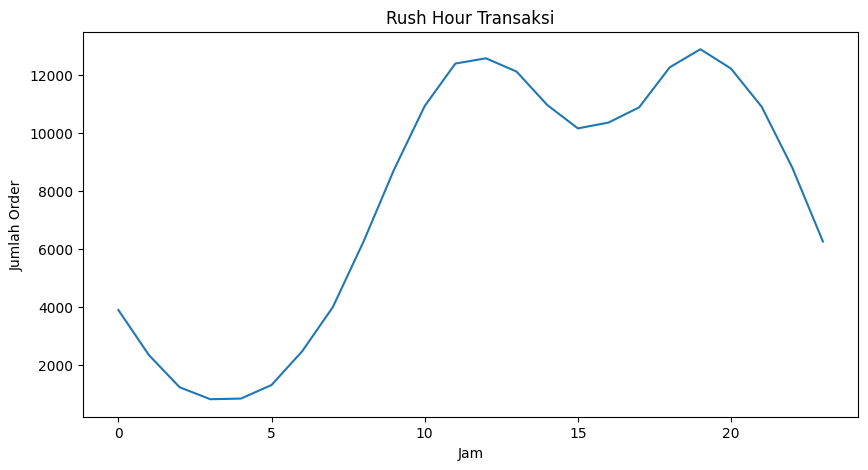

In [ ]:
hourly_orders = df.groupby('Hour')['Order ID'].count()


plt.figure(figsize=(10,5))
hourly_orders.plot()
plt.title("Rush Hour Transaksi")
plt.xlabel("Jam")
plt.ylabel("Jumlah Order")
plt.show()

digunakan untuk mengidentifikasi jam sibuk dalam aktivitas transaksi

In [ ]:
ts = df.groupby(df['Order Date'].dt.date)['Order ID'].nunique()
ts.index = pd.to_datetime(ts.index)

train = ts[:-30]
test = ts[-30:]

# ARIMA
model = ARIMA(train, order=(5,1,0))
model_fit = model.fit()

pred_arima = model_fit.forecast(steps=30)

mae_arima = mean_absolute_error(test, pred_arima)

pred_ma = test.shift(1).fillna(method='bfill')
mae_ma = mean_absolute_error(test, pred_ma)

# Baseline
print("MAE ARIMA:", mae_arima)
print("MAE Moving Average:", mae_ma)

MAE ARIMA: 62.02131832981252
MAE Moving Average: 50.86666666666667


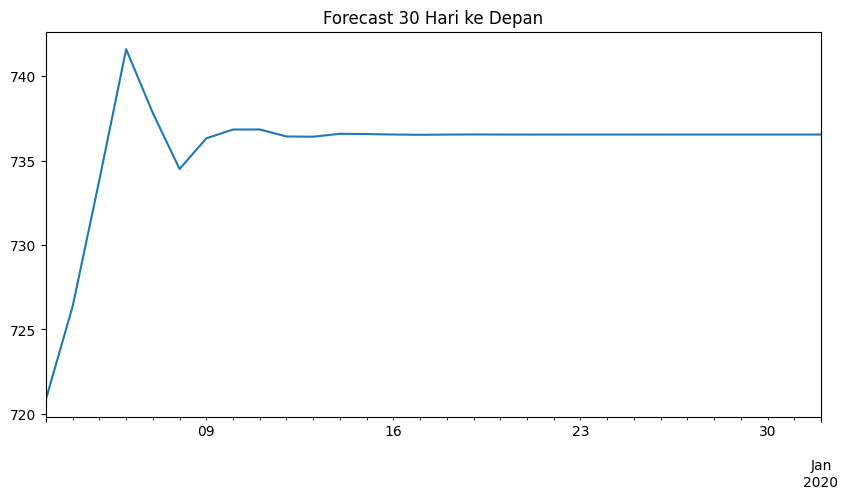

In [ ]:
future = model_fit.forecast(steps=30)

future.plot(figsize=(10,5))
plt.title("Forecast 30 Hari ke Depan")
plt.show()

model dengan MAE lebih kecil dipilih sebagai model terbaik untuk forecasting

1. Mengapa penting menganalisis tren waktu (trend & seasonality) sebelum membuat model forecasting, dan bagaimana pengabaian pola musiman bisa memengaruhi keputusan bisnis? Jelaskan dengan contoh bagaimana prediksi yang mengabaikan seasonality dapat menyebabkan salah perencanaan stok atau kampanye pemasaran.


Menganalisis trend dan seasonality penting karena data time series biasanya punya pola tertentu, bukan acak. Dengan memahami pola ini, hasil forecasting jadi lebih akurat. kalau pola musiman diabaikan, prediksi bisa meleset. Misalnya, saat ada promo besar atau akhir pekan biasanya transaksi naik. Kalau ini tidak diperhitungkan, perusahaan bisa salah stok barang bisa kehabisan saat permintaan tinggi atau malah overstock saat sepi. Hal yang sama juga bisa terjadi pada strategi marketing yang jadi kurang tepat sasaran.

2. Bagaimana metrik agregasi berbeda (harian, mingguan, bulanan) membantu tim bisnis dalam mengambil keputusan operasional dan strategis? Berikan contoh keputusan yang lebih tepat dibuat dengan data mingguan dibandingkan data harian, atau sebaliknya.
Tools


Perbedaan agregasi data membantu melihat bisnis dari sudut pandang yang berbeda.
data harian cocok untuk keputusan operasional, seperti menentukan jam promo atau melihat aktivitas harian. data mingguan lebih stabil untuk mengevaluasi performa, misalnya hasil campaign. sedangkan data bulanan lebih cocok untuk keputusan strategis seperti target penjualan atau perencanaan budget. contohnya, evaluasi campaign lebih pas pakai data mingguan, sementara penentuan target bisnis lebih relevan pakai data bulanan.